In [1]:
pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 13.6 MB/s eta 0:00:00


Fan speed: 64.13


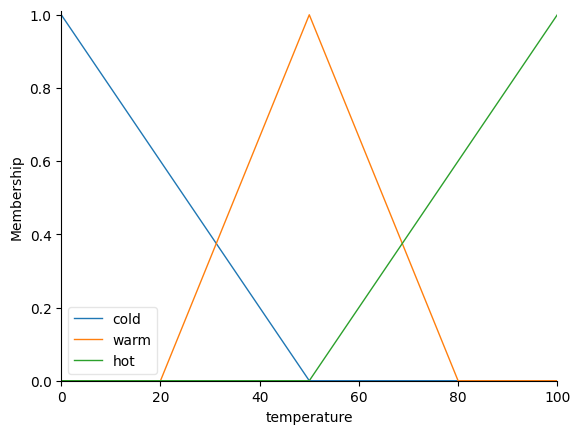

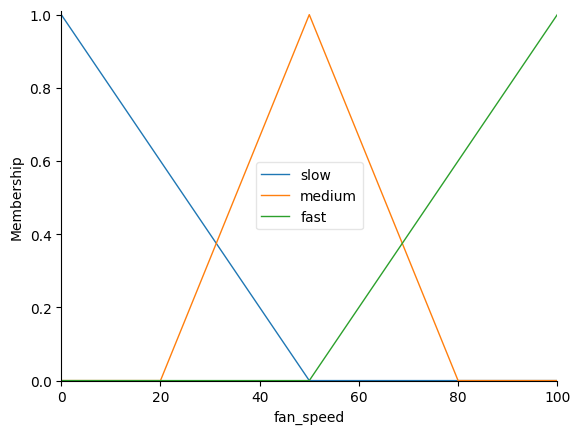

In [2]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

temperature = ctrl.Antecedent(np.arange(0, 101, 1), 'temperature')
fan_speed = ctrl.Consequent(np.arange(0, 101, 1), 'fan_speed')

temperature['cold'] = fuzz.trimf(temperature.universe, [0, 0, 50])
temperature['warm'] = fuzz.trimf(temperature.universe, [20, 50, 80])
temperature['hot'] = fuzz.trimf(temperature.universe, [50, 100, 100])

fan_speed['slow'] = fuzz.trimf(fan_speed.universe, [0, 0, 50])
fan_speed['medium'] = fuzz.trimf(fan_speed.universe, [20, 50, 80])
fan_speed['fast'] = fuzz.trimf(fan_speed.universe, [50, 100, 100])

rule1 = ctrl.Rule(temperature['cold'], fan_speed['slow'])
rule2 = ctrl.Rule(temperature['warm'], fan_speed['medium'])
rule3 = ctrl.Rule(temperature['hot'], fan_speed['fast'])

fan_control = ctrl.ControlSystem([rule1, rule2, rule3])
fan_simulation = ctrl.ControlSystemSimulation(fan_control)

fan_simulation.input['temperature'] = 70
fan_simulation.compute()

print(f"Fan speed: {fan_simulation.output['fan_speed']:.2f}")

temperature.view()
fan_speed.view()